In [1]:
import argparse
import time
import torch
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torch_geometric.logging import log
import easydict
import rdkit
from rdkit import Chem
import torch_geometric
import torch_geometric.utils.smiles as smiles
import random
import numpy as np
from torch.nn import Linear
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.nn import global_mean_pool
import networkx as nx
import matplotlib.pyplot as plt
import itertools
import community as community_louvain
import matplotlib.cm as cm
import os

In [2]:
parser = argparse.ArgumentParser()
args = easydict.EasyDict({
    "dataset": 'MUTAG',
    "batch_size": 128,
    "hidden_channels": 32,
    "lr": 0.0005,
    "epochs": 2000,
})

In [3]:
dataset = TUDataset(root='./mutag_data', name=args.dataset).shuffle()
dataset

MUTAG(188)

In [4]:
torch.unique(dataset.y)

tensor([0, 1])

In [5]:
train_loader = DataLoader(dataset[:0.9], args.batch_size, shuffle=True)
test_loader = DataLoader(dataset[0.9:], args.batch_size)

In [6]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super(GCN, self).__init__()
        torch.manual_seed(12345)
        self.conv1 = GCNConv(dataset.num_node_features, args.hidden_channels)
        self.conv2 = GCNConv(args.hidden_channels, args.hidden_channels)
        self.conv3 = GCNConv(args.hidden_channels, args.hidden_channels)
        self.lin = Linear(args.hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.lin(x)

        return x

def train():
    model.train()

    total_loss = 0
    for data in train_loader:
        #print(data.batch)
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        loss = F.cross_entropy(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += float(loss) * data.num_graphs
    return total_loss / len(train_loader.dataset)


@torch.no_grad()
def test(loader):
    model.eval()

    total_correct = 0
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.batch)
        pred = out.argmax(dim=-1)
        #softmax = out.softmax(dim=-1)
        total_correct += int((pred == data.y).sum())
    return total_correct / len(loader.dataset)

In [7]:
def evaluate_gnn(graph):
    with torch.no_grad():
        model.eval()
        graph = graph.to(device)
        # The pred is not used for accuracy, the softmax is used
        out = model(graph.x.float(), graph.edge_index, graph.batch)
        pred = out.argmax(dim=-1)

        # Getting class prediction probabilities from the softmax layer
        softmax = out.softmax(dim=-1)

        correct = (pred == graph.y)
        correct_indices = [i for i, x in enumerate(correct.tolist()) if x]

        # Taking softmax values of the nodes for which prediction is correct
        softmax_pred_list = [softmax.tolist()[i] for i in correct_indices]

        return softmax_pred_list, correct_indices

In [8]:
softmax_dict_list = []
max_pred_list = []
avg_max_pred_list = []
class_smile_list = []
class_graph_list = []
graph_dict_list = []

In [9]:
def get_max_pred(softmax_dict,i):
    prob_class0_dict = {}
    prob_class1_dict = {}
    
    for graph in softmax_dict:
        if len(softmax_dict[graph]) > 0:
            list0 = []
            list1 = []
    
            for prob in softmax_dict[graph]:
                list0.append(prob[0])
                list1.append(prob[1])
    
        #Taking max probability of all nodes of each class in a graph
        if len(list0) != 0:
            prob_class0_dict[graph] = max(list0)
        if len(list1) != 0:
            prob_class1_dict[graph] = max(list1)
    
    max_pred0 = max(prob_class0_dict.values())
    max_pred1 = max(prob_class1_dict.values())

    print('Run'+str(i), max_pred0, max_pred1)
    max_pred_list.append([max_pred0, max_pred1])
    
    avg_max_pred = (max_pred0+max_pred1)/2
    avg_max_pred_list.append(avg_max_pred)
    
    graph_dict_list.append(graph_dict)
    softmax_dict_list.append(softmax_dict)

    class0_smile = max(prob_class0_dict, key=prob_class0_dict.get)
    class1_smile = max(prob_class1_dict, key=prob_class1_dict.get)

    class_smile_list.append([class0_smile,class1_smile])
    print(class0_smile)
    print(class1_smile)
    
    class_graph_list.append([graph_dict.get(class0_smile), graph_dict.get(class1_smile)])

In [10]:
#['C', 'N', 'O', 'F', 'I', 'Cl', 'Br']
atomic_numbers = {0: 6, 1: 7, 2: 8, 3: 9, 4: 53, 5: 17, 6: 35}
edge_types = {0: 'AROMATIC', 1: 'SINGLE', 2: 'DOUBLE', 3: 'TRIPLE'}


for i in range(0,10):
    
    if torch.cuda.is_available():
        device = torch.device('cuda')
    else:
        device = torch.device('cpu')
    
    model = GCN(hidden_channels=args.hidden_channels).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
    criterion = torch.nn.CrossEntropyLoss()
    

    best_test_acc = 0
    start_patience = patience = 100
    for epoch in range(1, args.epochs + 1):
        loss = train()
        train_acc = test(train_loader)
        test_acc = test(test_loader)
        if epoch % 200 == 0:
            log(Epoch=epoch, Loss=loss, Train=train_acc, Test=test_acc)
        if best_test_acc <= test_acc:
            patience = start_patience
            best_test_acc = test_acc
        else:
            patience -= 1
    
        if patience <= 0:
            print('Stopping training as validation accuracy did not improve '
                  f'for {start_patience} epochs')
            break


    f = open('final_smiles.txt', 'r')
    list_smiles = []
    unique_labels = [0, 1]
    softmax_dict = {}
    graph_dict = {}
    for l in f:
    
        if l != 'None\n':
            list_smiles.append(l)
            
            graph = smiles.from_smiles(l)
            mol = Chem.MolFromSmiles(l)
    
            node_type_list = []
            for atom in mol.GetAtoms():
                atomic_no = atom.GetAtomicNum()
                node_type_list.append(list(atomic_numbers.keys())[list(atomic_numbers.values()).index(atomic_no)])
            graph.x = F.one_hot(torch.tensor(node_type_list), num_classes=len(atomic_numbers.keys()))
    
            graph.y = torch.tensor(random.choice(unique_labels)).to(torch.int64)
    
            edge_type_list = []
            for bond in mol.GetBonds():
                edge = str(bond.GetBondType())
                edge_type_list.append(list(edge_types.keys())[list(edge_types.values()).index(edge)])
            if edge_type_list:
                graph.edge_attr = F.one_hot(torch.tensor(edge_type_list), num_classes=len(edge_types.keys()))
            else:
                graph.edge_attr = torch.zeros(len(edge_types.keys())).to(torch.int64)
    
            graph.batch = torch.Tensor([0]).to(torch.int64)
            smile_str = str(graph.smiles).strip()
            graph.pop('smiles')
    
            softmax, correct_pred = evaluate_gnn(graph)
            if correct_pred:
                softmax_dict[smile_str] = softmax                
                graph_dict[smile_str] = graph
  

    get_max_pred(softmax_dict,i)

Epoch: 200, Loss: 0.5018, Train: 0.7278, Test: 0.6842
Stopping training as validation accuracy did not improve for 100 epochs
Run0 0.9999996423721313 1.0
C=C1[N+]2([O-])O[N+]1([O-])O2
CC=C=CC(C)C
Epoch: 200, Loss: 0.5018, Train: 0.7278, Test: 0.6842
Stopping training as validation accuracy did not improve for 100 epochs
Run1 0.9999996423721313 1.0
C=C1[N+]2([O-])O[N+]1([O-])O2
CC=C=CC(C)C
Epoch: 200, Loss: 0.5018, Train: 0.7278, Test: 0.6842
Stopping training as validation accuracy did not improve for 100 epochs
Run2 0.9999990463256836 0.9999998807907104
CNN=O
C=C=CCC
Epoch: 200, Loss: 0.5018, Train: 0.7278, Test: 0.6842
Stopping training as validation accuracy did not improve for 100 epochs
Run3 0.9999995231628418 0.9999998807907104
CN(O)O[N+]([O-])(O)O
C=C=CCC
Epoch: 200, Loss: 0.5018, Train: 0.7278, Test: 0.6842
Stopping training as validation accuracy did not improve for 100 epochs
Run4 0.9999995231628418 0.9999997615814209
CN(O)O[N+]([O-])(O)O
C=CC(C)C
Epoch: 200, Loss: 0.5018, Tr

In [11]:
avg_max_pred_list

[0.9999998211860657,
 0.9999998211860657,
 0.999999463558197,
 0.9999997019767761,
 0.9999996423721313,
 0.9999998211860657,
 0.9999995231628418,
 0.9999992847442627,
 0.9999997615814209,
 0.9999997019767761]

In [12]:
np.mean(avg_max_pred_list)

0.9999996542930603

In [13]:
m = max(avg_max_pred_list)
index = avg_max_pred_list.index(m)
index

0

In [14]:
atom_dict = {0: 'C', 1: 'N', 2: 'O', 3: 'F', 4: 'I', 5: 'Cl', 6: 'Br'}
color = {0: 'g', 1: 'r', 2: 'b', 3: 'c', 4: 'm', 5: 'w', 6: 'y'}
def graph_draw(g: torch_geometric.data.Data):
    attr= g.x.argmax(dim=1).tolist()
    # Convert to networkx
    g = torch_geometric.utils.to_networkx(g, to_undirected=True)

    labels = {}
    node_color = []
    for i in range(len(attr)):
        labels[i] = atom_dict.get(attr[i])
        node_color.append(color.get(attr[i]))

    nx.draw(g, labels=labels, node_color=node_color)
    plt.show()

In [15]:
class0_smile = class_smile_list[index][0]
class1_smile = class_smile_list[index][1]

In [16]:
print(class0_smile)
print(class1_smile)

C=C1[N+]2([O-])O[N+]1([O-])O2
CC=C=CC(C)C


In [17]:
max_pred0 = max_pred_list[index][0]
max_pred1 = max_pred_list[index][1]

In [18]:
print(max_pred0)
print(max_pred1)

0.9999996423721313
1.0


In [19]:
graph_dict_ind = graph_dict_list[index]

Explanation graph for class 0

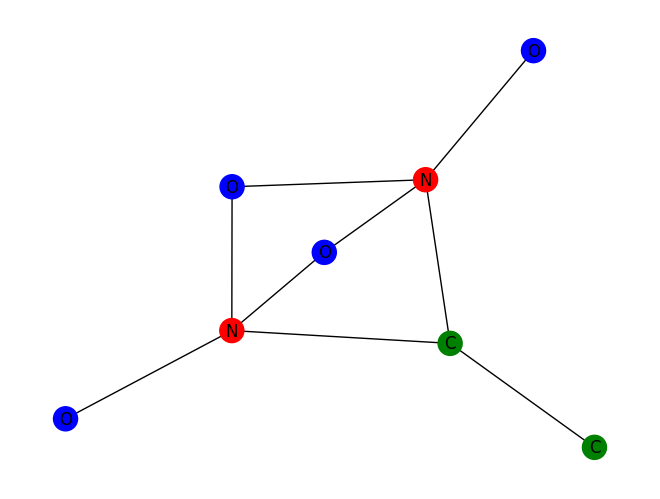

In [20]:
graph_draw(graph_dict_ind[class0_smile])

Explanation graph for class 1

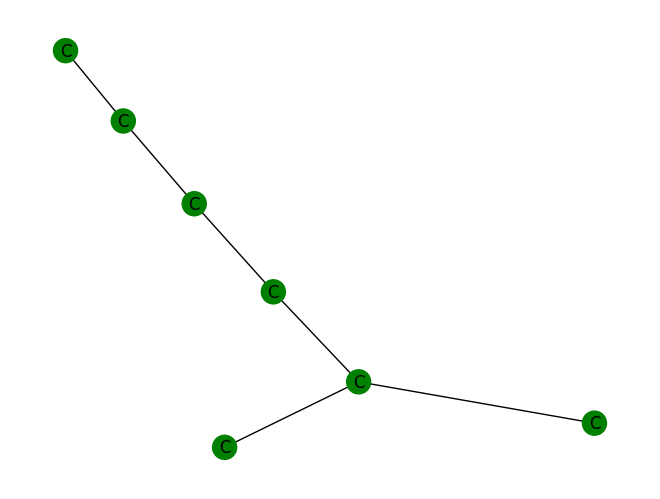

In [21]:
graph_draw(graph_dict_ind[class1_smile])

Fidelity

In [22]:
def detect_community(G):
    partition = community_louvain.best_partition(G)

In [23]:
motifs_path = '../motif_mutag/'
files_motif = os.listdir(motifs_path)

In [24]:
# for index_m, file_m in enumerate(files_motif):
#     filepath_m = os.path.join(motifs_path, file_m)
#     print(filepath_m)

In [25]:
def get_avg_fidelity(graph_list):
    class_avg_fidelity = []
    for g in graph_list:
        expln_graph = torch_geometric.utils.to_networkx(g, to_undirected=True)
        fid_score_list = []       
        for index_m, file_m in enumerate(files_motif):
            filepath_m = os.path.join(motifs_path, file_m)
            
            motif_graph = nx.read_gexf(filepath_m)

            GM = nx.algorithms.isomorphism.GraphMatcher(expln_graph,motif_graph)
            x = 1 if GM.subgraph_is_isomorphic() else 0    
            fid_score_list.append(x)

        class_avg_fidelity.append(np.mean(fid_score_list))

    return np.mean(class_avg_fidelity) 

In [26]:
avg_fidelity_list = []

for i in range(0,10):
    avg_fidelity = get_avg_fidelity(class_graph_list[i])

    print('Run'+str(i),avg_fidelity)
    avg_fidelity_list.append(avg_fidelity)
print(np.mean(avg_fidelity_list))

Run0 0.23404255319148937
Run1 0.23404255319148937
Run2 0.18085106382978722
Run3 0.21808510638297873
Run4 0.2154255319148936
Run5 0.23404255319148937
Run6 0.2154255319148936
Run7 0.2526595744680851
Run8 0.2526595744680851
Run9 0.21808510638297873
0.225531914893617
